### All Imports

In [78]:
import os
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing_extensions import TypedDict, List, Literal
from langchain.messages import HumanMessage, SystemMessage
from langchain.tools import tool
from tavily import TavilyClient
from pydantic import BaseModel, PositiveInt, Field
from pprint import pprint
from IPython.display import Markdown, display, Image
from langgraph.prebuilt import ToolNode

In [79]:
load_dotenv(".env")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [80]:
basic_llm = ChatGroq(model="llama-3.1-8b-instant", api_key = GROQ_API_KEY, temperature=0)
advanced_llm = ChatGroq(model="llama-3.1-8b-instant", api_key = GROQ_API_KEY, temperature=0)

In [81]:
tavily_client = TavilyClient(api_key=TAVILY_API_KEY)

In [82]:
# Prompts - Read Content from Files
f = open("./prompts/generations.md")
GENERATION_PROMPT = f.read()
f = open("./prompts/optimisation.md")
OPTIMISATION_PROMPT = f.read()
f = open("./prompts/scoring.md")
SCORING_PROMPT = f.read()
f = open("./prompts/validation.md")
VALIDATION_PROMPT = f.read()

In [83]:
# Output of scroing agent
class Score(BaseModel):
    score: int = Field(
        description="score between 0 and 100"
    )
    description: str = Field(
        description="clear and detailed explanation of how the score was determined"
    )

# Output of generation offre
class Offre(BaseModel):
    offre: str = Field(
        description="""
            Return either:
                - A personalized marketing offer.
                - A clear human action message explaining that more customer information is required.
        """
    )

# Output of validation offre
class IsValid(BaseModel):
    is_valid: bool = Field(
        description="Boolean value indicating whether the offer valid or invalid."
    )
    description: str = Field(
        description="A clear and detailed explanation of why the offer is valid or invalid."
    )

class MarketingState(TypedDict):
    user_input: str
    client_data: str
    score: Score
    offer: Offre
    valid: IsValid
    optimized_version: Offre
    next: Literal["INIT", "FETCHING", "SCORING", "GENERATION", "VALIDATION", "OPTMISATION", "END"]
    messages: list()

#### Fetcher Agent

In [84]:
# Fetcher Agent
"""
    In Backend We Should Handle This Part
        --> User Enter Prompt
        --> User Select CSV, Excel
        --> Use Use MCP 
"""

# This agent can use tools to connect to DB, Read execel files, ...
def fetcher_agent(state: MarketingState):
    """
        Decide where is the data: (Database tool, File tool, )
    """
    client_data = """
        I have a client who spent 10 dollars on online shopping products during the last month.
        The client made 3 purchases, mainly buying electronics and accessories.
        Their average order value is around 3.33 dollars, and they usually purchase during weekends.
        The client has been active for 6 months and shows moderate engagement with marketing campaigns.
    """
    return {"client_data": str(client_data), "next": "SCORING"}


#### Scoring Agent

In [85]:
# Tools for Scoring Agent
@tool
def getHowToScoreUser(query: str, limit: int) -> list:
    """
        Get from internet how to score user
        Args:
            query: Search term to look for
            limit: Maximum number of results to return
    """
    print("TOOL CALL: getHowToScoreUser")
    response = tavily_client.search(query=query, max_results=limit)
    results = response.get("results", [])
    content = []
    for res in results:
        content.append({"url": res.get("url", ""), "content": res.get("content", "")})
    return content

@tool
def getBusinessInformation():
    """
        Get business Informations For Customer Scoring
    """
    print("TOOL CALL: getBusinessInformation")
    # should get file that contain (Brand, Contact to Use, Ton, ...)
    return "No business Informations Yet"

# Scoring Agent
def scoring_agent(state: MarketingState):
    print("Scoring ...")
    messages = [
        SystemMessage(content=SCORING_PROMPT),
        HumanMessage(content=f"""
            Customer Data: \n\n
            {state.get("client_data", "no customer data available")}
        """),
    ]
    
    llm_with_tools = basic_llm.bind_tools([getHowToScoreUser, getBusinessInformation])
    response = llm_with_tools.invoke(messages)
    return {
        "messages": [response]
    }


tool_node_scoring = ToolNode(tools=[getHowToScoreUser, getBusinessInformation])

def should_continue_to_scoring_tool(state: MarketingState):
    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "scoring_tools"

    return END

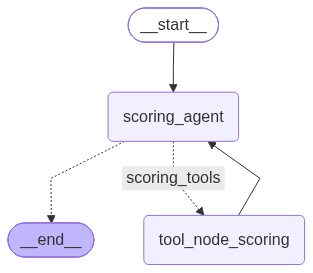

In [86]:
workflow_scoring = StateGraph(MarketingState)
workflow_scoring.add_node("scoring_agent", scoring_agent)
workflow_scoring.add_node("tool_node_scoring", tool_node_scoring)
workflow_scoring.add_edge("tool_node_scoring","scoring_agent")
workflow_scoring.add_conditional_edges("scoring_agent",
        should_continue_to_scoring_tool, 
        {
            "scoring_tools": "tool_node_scoring",
            END: END
        }
)
workflow_scoring.set_entry_point("scoring_agent")
scoring_app = workflow_scoring.compile()
display(Image(scoring_app.get_graph().draw_mermaid_png()))

In [87]:
# Test Agent
client_data = fetcher_agent({})["client_data"]
print(client_data)
state: MarketingState = {
    "user_input": "Score this customer",
    "client_data": client_data,
    "marketing_offer": "",
    "score": None,
    "next": "SCORING",
}
scoring_app.invoke(input=state)



        I have a client who spent 10 dollars on online shopping products during the last month.
        The client made 3 purchases, mainly buying electronics and accessories.
        Their average order value is around 3.33 dollars, and they usually purchase during weekends.
        The client has been active for 6 months and shows moderate engagement with marketing campaigns.
    
Scoring ...
TOOL CALL: getBusinessInformation
Scoring ...
TOOL CALL: getBusinessInformation
Scoring ...
TOOL CALL: getBusinessInformation
Scoring ...
TOOL CALL: getBusinessInformation
Scoring ...


KeyboardInterrupt: 

#### Generation Agent

In [ ]:
# Tools
@tool
def getExternalInformation() -> str:
    """
        Retrieves external business information.
        Args:
            This tool does not require any arguments.
    """
    return """
        Business Type: Coffe Shope
    """

@tool("HowToWriteMarketingOffre")
def HowToWriteMarketingOffre(query: str, limit: int) -> list:
    """
        Search On Internet Using Of How to Write Marketing Offre
        Args:
            query: Search term to look for
            limit: Maximum number of results to return
    """
    response = tavily_client.search(query=query, max_results=limit)
    results = response.get("results", [])
    content = []
    for res in results:
        content.append({"url": res.get("url", ""), "content": res.get("content", "")})
    return content

# Generation Agent
def generation_agent(state: MarketingState):
    customer_data = state.get("client_data", "No Client Data")
    customer_score = state.get("score", "0")
    user_input = state.get('user_input', "Generate Marketing Offre based on the customer data")
    messages = [
        SystemMessage(content=GENERATION_PROMPT),
        HumanMessage(
            content=f"""
            Generate marketing offer.

            User Request:
            {user_input}

            Customer Data:
            {customer_data}
            
            Customer Score:
            {customer_score}/100
            """
        )
    ]
    
    llm_with_tools = basic_llm.bind_tools([HowToWriteMarketingOffre, getExternalInformation])
    tool_response = llm_with_tools.invoke(messages)
    print(tool_response)
    final_messages = [*messages, tool_response]
    response = llm_with_tools.with_structured_output(Offre).invoke(final_messages)
    return {
        "offre": response.offre,
        "next": "VALIDATION"
    }


In [ ]:
# Test Generation Agent
client_data = fetcher_agent({})["client_data"]
print(client_data)
state: MarketingState = {
    "user_input": "Generate Marketing Offre based on the customer data",
    "client_data": client_data,
    "offre": None,
    "score": 0,
}
result = generation_agent(state)


{'technical_info': {'device': 'Desktop', 'browser': 'Chrome', 'os': 'Linux'}}
content='' additional_kwargs={'tool_calls': [{'id': 'q4szea6be', 'function': {'arguments': '{}', 'name': 'getExternalInformation'}, 'type': 'function'}, {'id': 'rvmdgs6xc', 'function': {'arguments': '{"limit":10,"query":"Marketing offer for Linux Desktop user with low Customer Score"}', 'name': 'HowToWriteMarketingOffre'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 457, 'total_tokens': 498, 'completion_time': 0.061541508, 'completion_tokens_details': None, 'prompt_time': 0.025643551, 'prompt_tokens_details': None, 'queue_time': 0.018543825, 'total_time': 0.087185059}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_8639719ff2', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019fb52b-959e-7132-9824-0cc987f8088a-0' tool_calls=[{'name': 'getExternalInformation', 'args': {},

In [ ]:
display(Markdown(result.get("offre")))

Get 20% off on our Linux-compatible software suite. Limited time offer for new customers. Upgrade now and boost your productivity!

#### Validation Agent

In [ ]:
# Tools
@tool
def getValidationRules():
    """
        Get Rules To Validate The Offre
    """
    
    # Read File From Data Called validation.md
    return "no business rules"

# Validation Agent
def validation_agent(state: MarketingState):
    # Get Offre
    offre = state.get("offre", "no offre")
    messages = [SystemMessage(content=VALIDATION_PROMPT), HumanMessage(content=
        f"""
        Offre: \n\n
            {offre}
        """
    )]
    
    response = basic_llm.with_structured_output(IsValid).invoke(messages)
    print(type(response.is_valid))
    print(response.is_valid)
    print(response.description)
    if response.is_valid:
        return {"offre": response, "next": "END"}
    return {"offre": response, "next": "OPTMISATION"}

In [ ]:
# Test Validation Agent
offre = """Bonjour Ahmed,
Nous sommes ravis de vous proposer une offre spéciale en votre nom !
Vous avez déjà dépensé 209,70€ chez nous
Nous avons remarqué que vous avez acheté des produits de qualité tels que des parfums, des chaussures et des t-shirts. Nous sommes convaincus que vous allez adorer notre nouvelle collection de produits de luxe !
Découvrez nos meilleures offres
Parfum exclusif : 50% de réduction sur notre nouveau parfum, disponible uniquement pendant une semaine !
Chaussures de luxe : 30% de réduction sur nos chaussures de luxe, conçues pour les pieds les plus exigeants !
T-shirt premium : 20% de réduction sur nos t-shirts premium, faits avec les matériaux les plus confortables !
N'oubliez pas de profiter de nos offres spéciales
Livraison gratuite : sur tous les commandes supérieures à 100€
Retour gratuit : sur tous les produits achetés chez nous
Cliquez ici pour découvrir nos offres [lien vers la page d'offres]
Nous sommes impatients de vous voir chez nous !
Cordialement, L'équipe de [votre nom de l'entreprise]
"""

# Test Generation Agent
state: MarketingState = {
    "offre": offre,
}
result = validation_agent(state)

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=IsValid> {"is_valid": false, "description": "L\\\'offre est considérée comme non valide car elle ne respecte pas les règles de base de validation. En effet, l\\\'offre est conditionnelle et nécessite un achat minimum de 100€ pour bénéficier de la livraison gratuite."}</function>'}}

#### Optimisation Offre

In [ ]:
# Tools for Optimisation offre


# Agent for offre Optmisation
def optmisation_agent(state: MarketingState):
    # Get Offre
    offre = state.get("offre", "None")
    if (type(state.get("valid")) == "IsValid"):
        feedback = state.get("valid").description
    else:
        feedback = "None"
    messages = [SystemMessage(content=OPTIMISATION_PROMPT), HumanMessage(content=f"""
        Based on This feedback: \n\n
            {feedback}
        Optimise this Offre: \n\n 
            {offre}
        """)]
    
    response = basic_llm.with_structured_output(Offre).invoke(messages)
    return {"offre": response, "next": "END"}

In [ ]:
# Test Validation Agent
offre = """Bonjour Ahmed,
Nous sommes ravis de vous proposer une offre spéciale en votre nom !
Vous avez déjà dépensé 209,70€ chez nous
Nous avons remarqué que vous avez acheté des produits de qualité tels que des parfums, des chaussures et des t-shirts. Nous sommes convaincus que vous allez adorer notre nouvelle collection de produits de luxe !
Découvrez nos meilleures offres
Parfum exclusif : 50% de réduction sur notre nouveau parfum, disponible uniquement pendant une semaine !
Chaussures de luxe : 30% de réduction sur nos chaussures de luxe, conçues pour les pieds les plus exigeants !
T-shirt premium : 20% de réduction sur nos t-shirts premium, faits avec les matériaux les plus confortables !
N'oubliez pas de profiter de nos offres spéciales
Livraison gratuite : sur tous les commandes supérieures à 100€
Retour gratuit : sur tous les produits achetés chez nous
Cliquez ici pour découvrir nos offres [lien vers la page d'offres]
Nous sommes impatients de vous voir chez nous !
Cordialement, L'équipe de [votre nom de l'entreprise]
"""

# Test Generation Agent
client_data = fetcher_agent({})["client_data"]
state: MarketingState = {
    "user_input": "",
    "client_data": client_data,
    "marketing_offer": "",
    "score": 85,
    "offre": offre,
    "next": "SCORING",
    "valid": None
}
result = optmisation_agent(state)
display(Markdown(result.get('offre').offre))

Bonjour Ahmed,
Nous sommes ravis de vous proposer une offre spéciale en votre nom !
Vous avez déjà dépensé 209,70€ chez nous
Nous avons remarqué que vous avez acheté des produits de qualité tels que des parfums, des chaussures et des t-shirts. Nous sommes convaincus que vous allez adorer notre nouvelle collection de produits de luxe !
Découvrez nos meilleures offres
Parfum exclusif : 50% de réduction sur notre nouveau parfum, disponible uniquement pendant une semaine !
Chaussures de luxe : 30% de réduction sur nos chaussures de luxe, conçues pour les pieds les plus exigeants !
T-shirt premium : 20% de réduction sur nos t-shirts premium, faits avec les matériaux les plus confortables !
N'oubliez pas de profiter de nos offres spéciales
Livraison gratuite : sur tous les commandes supérieures à 100€
Retour gratuit : sur tous les produits achetés chez nous
Cliquez ici pour découvrir nos offres [lien vers la page d'offres]
Nous sommes impatients de vous voir chez nous !
Cordialement, L'équipe de [votre nom de l'entreprise]

#### Build graph

In [ ]:
# Routing
def router(state: MarketingState):
    return state["next"]

In [ ]:
workflow = StateGraph(MarketingState)

In [ ]:
workflow.add_node("fetcher_agent", fetcher_agent)
workflow.add_node("scoring_agent", scoring_agent)
# workflow.add_node("generation_agent", generation_agent)
# workflow.add_node("validation_agent", validation_agent)
# workflow.add_node("optmisation_agent", optmisation_agent)

workflow.set_entry_point(fetcher_agent)



